<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/lineartransformation_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-951266551.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


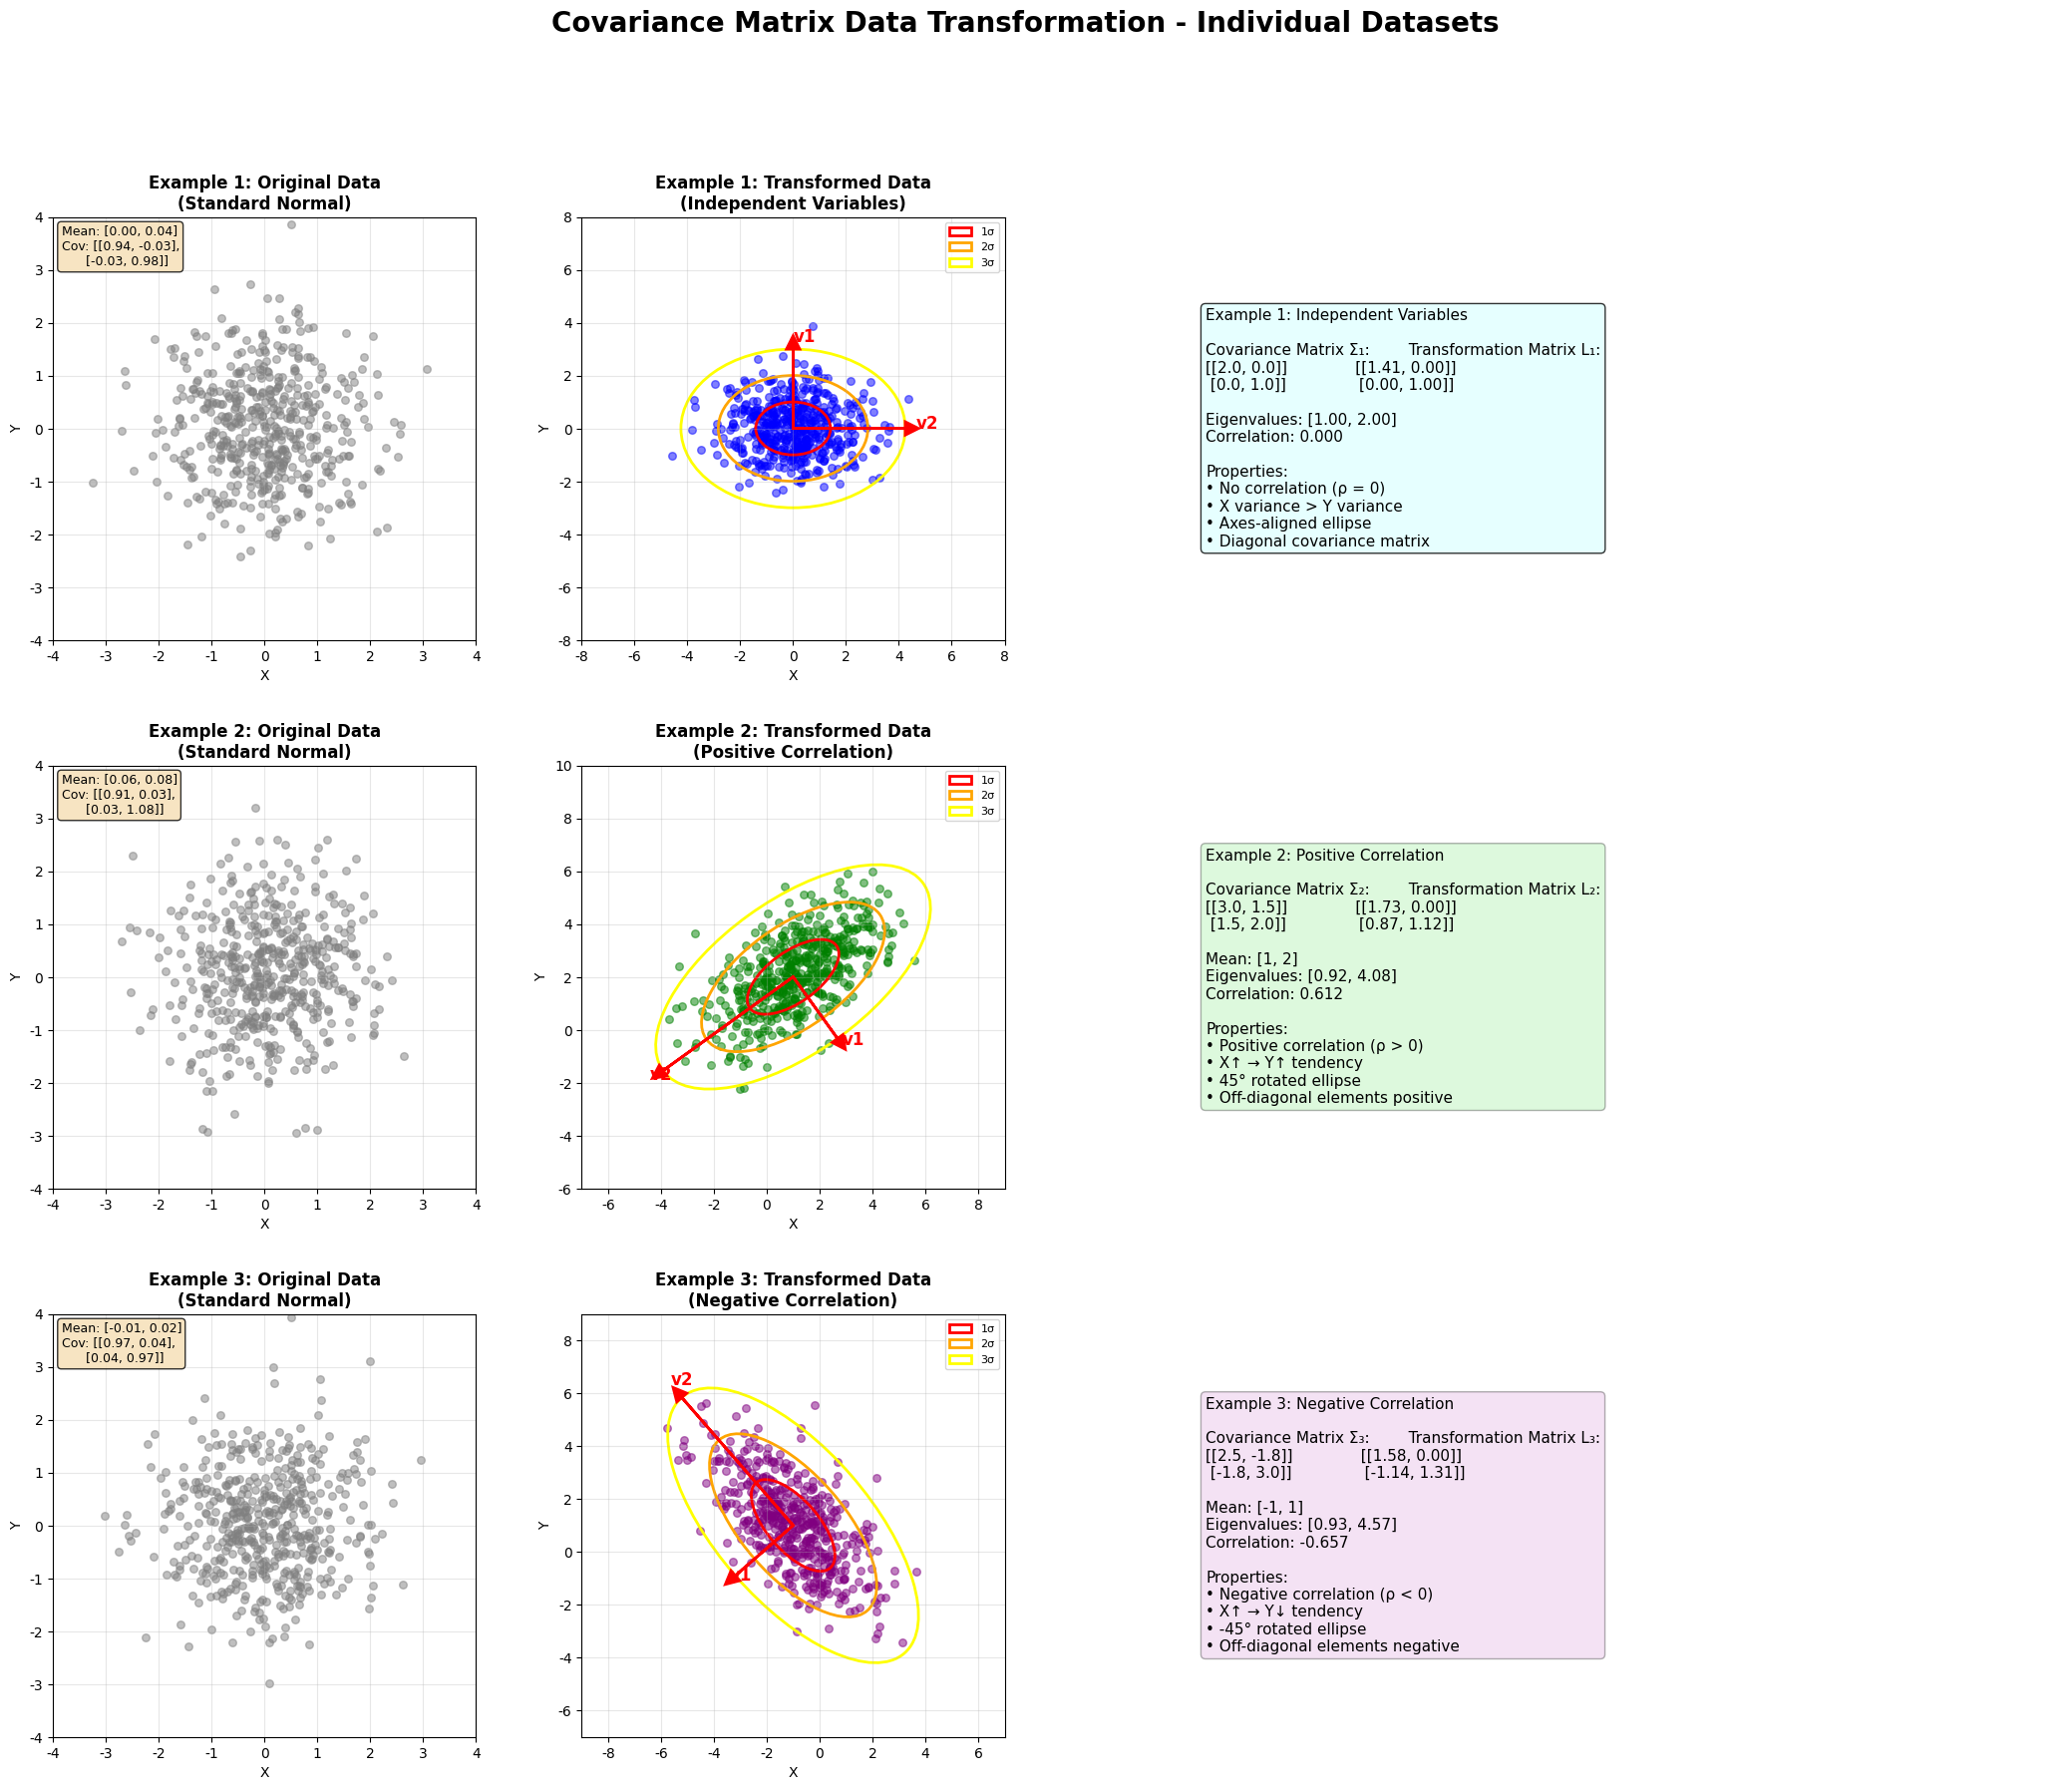

TRANSFORMATION VERIFICATION

Example 1:
----------------------------------------
Original Data Statistics:
  Mean: [0.004 0.035]
  Covariance:
[[ 0.935 -0.025]
 [-0.025  0.984]]

Transformed Data:
  Target Mean: [0, 0]
  Actual Mean: [0.005 0.035]
  Target Covariance:
[[2 0]
 [0 1]]
  Actual Covariance:
[[ 1.87  -0.036]
 [-0.036  0.984]]

Verification: L·L^T =
[[2. 0.]
 [0. 1.]]

Example 2:
----------------------------------------
Original Data Statistics:
  Mean: [0.063 0.079]
  Covariance:
[[0.914 0.029]
 [0.029 1.077]]

Transformed Data:
  Target Mean: [1, 2]
  Actual Mean: [1.109 2.143]
  Target Covariance:
[[3.  1.5]
 [1.5 2. ]]
  Actual Covariance:
[[2.743 1.428]
 [1.428 2.089]]

Verification: L·L^T =
[[3.  1.5]
 [1.5 2. ]]

Example 3:
----------------------------------------
Original Data Statistics:
  Mean: [-0.01   0.022]
  Covariance:
[[0.967 0.043]
 [0.043 0.968]]

Transformed Data:
  Target Mean: [-1, 1]
  Actual Mean: [-1.016  1.04 ]
  Target Covariance:
[[ 2.5 -1.8]
 [-1.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def plot_2d_gaussian(mean, cov, ax, n_std=3.0, color='blue', label=''):
    """
    2D 가우시안 분포를 타원으로 시각화
    """
    # 고유값과 고유벡터 계산
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # 타원의 각도 계산
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    # 타원의 너비와 높이
    width, height = 2 * n_std * np.sqrt(eigenvalues)

    # 타원 그리기
    ellipse = Ellipse(mean, width, height, angle=angle,
                      facecolor='none', edgecolor=color, linewidth=2,
                      linestyle='-', label=f'{n_std}σ')
    ax.add_patch(ellipse)

    return ellipse

# 3개의 독립적인 원본 데이터셋 생성 (표준 정규분포)
np.random.seed(42)  # 재현성을 위한 시드 설정
n_points = 500

# 각 예시별로 다른 원본 데이터 생성
original_data1 = np.random.randn(n_points, 2)  # 예시 1용
original_data2 = np.random.randn(n_points, 2)  # 예시 2용
original_data3 = np.random.randn(n_points, 2)  # 예시 3용

# 변환 함수
def transform_data(data, cov, mean=[0, 0]):
    # Cholesky 분해를 사용한 변환
    L = np.linalg.cholesky(cov)
    transformed = data @ L.T + mean
    return transformed, L

# Figure 설정
fig = plt.figure(figsize=(26, 20))
fig.suptitle('Covariance Matrix Data Transformation - Individual Datasets', fontsize=20, fontweight='bold')

# GridSpec을 사용해 레이아웃 구성
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.25, wspace=0.25)

# ========== 예시 1: 독립적인 변수 ==========
mean1 = [0, 0]
cov1 = [[2, 0],
        [0, 1]]

# 예시 1 - 원본 데이터
ax1_orig = fig.add_subplot(gs[0, 0])
ax1_orig.scatter(original_data1[:, 0], original_data1[:, 1], alpha=0.5, s=30, color='gray')
ax1_orig.set_xlim(-4, 4)
ax1_orig.set_ylim(-4, 4)
ax1_orig.set_aspect('equal')
ax1_orig.grid(True, alpha=0.3)
ax1_orig.set_title('Example 1: Original Data\n(Standard Normal)', fontsize=12, fontweight='bold')
ax1_orig.set_xlabel('X')
ax1_orig.set_ylabel('Y')

# 원본 데이터 1 통계 표시
orig_cov1 = np.cov(original_data1.T)
textstr1 = f'Mean: [{np.mean(original_data1[:, 0]):.2f}, {np.mean(original_data1[:, 1]):.2f}]\n'
textstr1 += f'Cov: [[{orig_cov1[0,0]:.2f}, {orig_cov1[0,1]:.2f}],\n'
textstr1 += f'      [{orig_cov1[1,0]:.2f}, {orig_cov1[1,1]:.2f}]]'
ax1_orig.text(0.02, 0.98, textstr1, transform=ax1_orig.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 예시 1 - 변환된 데이터
ax1_trans = fig.add_subplot(gs[0, 1])
transformed1, L1 = transform_data(original_data1, cov1, mean1)
ax1_trans.scatter(transformed1[:, 0], transformed1[:, 1], alpha=0.5, s=30, color='blue')
plot_2d_gaussian(mean1, cov1, ax1_trans, n_std=1, color='red')
plot_2d_gaussian(mean1, cov1, ax1_trans, n_std=2, color='orange')
plot_2d_gaussian(mean1, cov1, ax1_trans, n_std=3, color='yellow')

# 고유벡터 표시 (예시 1)
eigenvalues1, eigenvectors1 = np.linalg.eigh(cov1)
for i in range(2):
    eigen_vec = eigenvectors1[:, i] * np.sqrt(eigenvalues1[i]) * 3 # Scale by 3 standard deviations
    ax1_trans.arrow(mean1[0], mean1[1], eigen_vec[0], eigen_vec[1],
                    head_width=0.5, head_length=0.5, fc='red', ec='red',
                    linewidth=2, zorder=5)
    ax1_trans.text(mean1[0] + eigen_vec[0]*1.1, mean1[1] + eigen_vec[1]*1.1,
                   f'v{i+1}', fontsize=12, fontweight='bold', color='red')

ax1_trans.set_xlim(-8, 8)
ax1_trans.set_ylim(-8, 8)
ax1_trans.set_aspect('equal')
ax1_trans.grid(True, alpha=0.3)
ax1_trans.set_title('Example 1: Transformed Data\n(Independent Variables)', fontsize=12, fontweight='bold')
ax1_trans.set_xlabel('X')
ax1_trans.set_ylabel('Y')
ax1_trans.legend(loc='upper right', fontsize=8)

# 예시 1 - 행렬 정보
ax1_info = fig.add_subplot(gs[0, 2:])
ax1_info.axis('off')
eigenvalues1, eigenvectors1 = np.linalg.eigh(cov1)
correlation1 = cov1[0][1] / (np.sqrt(cov1[0][0]) * np.sqrt(cov1[1][1]))

info1 = f"""Example 1: Independent Variables

Covariance Matrix Σ₁:        Transformation Matrix L₁:
[[{cov1[0][0]:.1f}, {cov1[0][1]:.1f}]]              [[{L1[0,0]:.2f}, {L1[0,1]:.2f}]]
 [{cov1[1][0]:.1f}, {cov1[1][1]:.1f}]]               [{L1[1,0]:.2f}, {L1[1,1]:.2f}]]

Eigenvalues: [{eigenvalues1[0]:.2f}, {eigenvalues1[1]:.2f}]
Correlation: {correlation1:.3f}

Properties:
• No correlation (ρ = 0)
• X variance > Y variance
• Axes-aligned ellipse
• Diagonal covariance matrix"""

ax1_info.text(0.1, 0.5, info1, transform=ax1_info.transAxes,
             fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

# ========== 예시 2: 양의 상관관계 ==========
mean2 = [1, 2]
cov2 = [[3, 1.5],
        [1.5, 2]]

# 예시 2 - 원본 데이터
ax2_orig = fig.add_subplot(gs[1, 0])
ax2_orig.scatter(original_data2[:, 0], original_data2[:, 1], alpha=0.5, s=30, color='gray')
ax2_orig.set_xlim(-4, 4)
ax2_orig.set_ylim(-4, 4)
ax2_orig.set_aspect('equal')
ax2_orig.grid(True, alpha=0.3)
ax2_orig.set_title('Example 2: Original Data\n(Standard Normal)', fontsize=12, fontweight='bold')
ax2_orig.set_xlabel('X')
ax2_orig.set_ylabel('Y')

# 원본 데이터 2 통계 표시
orig_cov2 = np.cov(original_data2.T)
textstr2 = f'Mean: [{np.mean(original_data2[:, 0]):.2f}, {np.mean(original_data2[:, 1]):.2f}]\n'
textstr2 += f'Cov: [[{orig_cov2[0,0]:.2f}, {orig_cov2[0,1]:.2f}],\n'
textstr2 += f'      [{orig_cov2[1,0]:.2f}, {orig_cov2[1,1]:.2f}]]'
ax2_orig.text(0.02, 0.98, textstr2, transform=ax2_orig.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 예시 2 - 변환된 데이터
ax2_trans = fig.add_subplot(gs[1, 1])
transformed2, L2 = transform_data(original_data2, cov2, mean2)
ax2_trans.scatter(transformed2[:, 0], transformed2[:, 1], alpha=0.5, s=30, color='green')
plot_2d_gaussian(mean2, cov2, ax2_trans, n_std=1, color='red')
plot_2d_gaussian(mean2, cov2, ax2_trans, n_std=2, color='orange')
plot_2d_gaussian(mean2, cov2, ax2_trans, n_std=3, color='yellow')

# 고유벡터 표시 (예시 2)
eigenvalues2, eigenvectors2 = np.linalg.eigh(cov2)
for i in range(2):
    eigen_vec = eigenvectors2[:, i] * np.sqrt(eigenvalues2[i]) * 3 # Scale by 3 standard deviations
    ax2_trans.arrow(mean2[0], mean2[1], eigen_vec[0], eigen_vec[1],
                    head_width=0.5, head_length=0.5, fc='red', ec='red',
                    linewidth=2, zorder=5)
    ax2_trans.text(mean2[0] + eigen_vec[0]*1.1, mean2[1] + eigen_vec[1]*1.1,
                   f'v{i+1}', fontsize=12, fontweight='bold', color='red')

ax2_trans.set_xlim(-7, 9)
ax2_trans.set_ylim(-6, 10)
ax2_trans.set_aspect('equal')
ax2_trans.grid(True, alpha=0.3)
ax2_trans.set_title('Example 2: Transformed Data\n(Positive Correlation)', fontsize=12, fontweight='bold')
ax2_trans.set_xlabel('X')
ax2_trans.set_ylabel('Y')
ax2_trans.legend(loc='upper right', fontsize=8)

# 예시 2 - 행렬 정보
ax2_info = fig.add_subplot(gs[1, 2:])
ax2_info.axis('off')
eigenvalues2, eigenvectors2 = np.linalg.eigh(cov2)
correlation2 = cov2[0][1] / (np.sqrt(cov2[0][0]) * np.sqrt(cov2[1][1]))

info2 = f"""Example 2: Positive Correlation

Covariance Matrix Σ₂:        Transformation Matrix L₂:
[[{cov2[0][0]:.1f}, {cov2[0][1]:.1f}]]              [[{L2[0,0]:.2f}, {L2[0,1]:.2f}]]
 [{cov2[1][0]:.1f}, {cov2[1][1]:.1f}]]               [{L2[1,0]:.2f}, {L2[1,1]:.2f}]]

Mean: [{mean2[0]}, {mean2[1]}]
Eigenvalues: [{eigenvalues2[0]:.2f}, {eigenvalues2[1]:.2f}]
Correlation: {correlation2:.3f}

Properties:
• Positive correlation (ρ > 0)
• X↑ → Y↑ tendency
• 45° rotated ellipse
• Off-diagonal elements positive"""

ax2_info.text(0.1, 0.5, info2, transform=ax2_info.transAxes,
             fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# ========== 예시 3: 음의 상관관계 ==========
mean3 = [-1, 1]
cov3 = [[2.5, -1.8],
        [-1.8, 3]]

# 예시 3 - 원본 데이터
ax3_orig = fig.add_subplot(gs[2, 0])
ax3_orig.scatter(original_data3[:, 0], original_data3[:, 1], alpha=0.5, s=30, color='gray')
ax3_orig.set_xlim(-4, 4)
ax3_orig.set_ylim(-4, 4)
ax3_orig.set_aspect('equal')
ax3_orig.grid(True, alpha=0.3)
ax3_orig.set_title('Example 3: Original Data\n(Standard Normal)', fontsize=12, fontweight='bold')
ax3_orig.set_xlabel('X')
ax3_orig.set_ylabel('Y')

# 원본 데이터 3 통계 표시
orig_cov3 = np.cov(original_data3.T)
textstr3 = f'Mean: [{np.mean(original_data3[:, 0]):.2f}, {np.mean(original_data3[:, 1]):.2f}]\n'
textstr3 += f'Cov: [[{orig_cov3[0,0]:.2f}, {orig_cov3[0,1]:.2f}],\n'
textstr3 += f'      [{orig_cov3[1,0]:.2f}, {orig_cov3[1,1]:.2f}]]'
ax3_orig.text(0.02, 0.98, textstr3, transform=ax3_orig.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 예시 3 - 변환된 데이터
ax3_trans = fig.add_subplot(gs[2, 1])
transformed3, L3 = transform_data(original_data3, cov3, mean3)
ax3_trans.scatter(transformed3[:, 0], transformed3[:, 1], alpha=0.5, s=30, color='purple')
plot_2d_gaussian(mean3, cov3, ax3_trans, n_std=1, color='red')
plot_2d_gaussian(mean3, cov3, ax3_trans, n_std=2, color='orange')
plot_2d_gaussian(mean3, cov3, ax3_trans, n_std=3, color='yellow')

# 고유벡터 표시 (예시 3)
eigenvalues3, eigenvectors3 = np.linalg.eigh(cov3)
for i in range(2):
    eigen_vec = eigenvectors3[:, i] * np.sqrt(eigenvalues3[i]) * 3 # Scale by 3 standard deviations
    ax3_trans.arrow(mean3[0], mean3[1], eigen_vec[0], eigen_vec[1],
                    head_width=0.5, head_length=0.5, fc='red', ec='red',
                    linewidth=2, zorder=5)
    ax3_trans.text(mean3[0] + eigen_vec[0]*1.1, mean3[1] + eigen_vec[1]*1.1,
                   f'v{i+1}', fontsize=12, fontweight='bold', color='red')

ax3_trans.set_xlim(-9, 7)
ax3_trans.set_ylim(-7, 9)
ax3_trans.set_aspect('equal')
ax3_trans.grid(True, alpha=0.3)
ax3_trans.set_title('Example 3: Transformed Data\n(Negative Correlation)', fontsize=12, fontweight='bold')
ax3_trans.set_xlabel('X')
ax3_trans.set_ylabel('Y')
ax3_trans.legend(loc='upper right', fontsize=8)

# 예시 3 - 행렬 정보
ax3_info = fig.add_subplot(gs[2, 2:])
ax3_info.axis('off')
eigenvalues3, eigenvectors3 = np.linalg.eigh(cov3)
correlation3 = cov3[0][1] / (np.sqrt(cov3[0][0]) * np.sqrt(cov3[1][1]))

info3 = f"""Example 3: Negative Correlation

Covariance Matrix Σ₃:        Transformation Matrix L₃:
[[{cov3[0][0]:.1f}, {cov3[0][1]:.1f}]]              [[{L3[0,0]:.2f}, {L3[0,1]:.2f}]]
 [{cov3[1][0]:.1f}, {cov3[1][1]:.1f}]]               [{L3[1,0]:.2f}, {L3[1,1]:.2f}]]

Mean: [{mean3[0]}, {mean3[1]}]
Eigenvalues: [{eigenvalues3[0]:.2f}, {eigenvalues3[1]:.2f}]
Correlation: {correlation3:.3f}

Properties:
• Negative correlation (ρ < 0)
• X↑ → Y↓ tendency
• -45° rotated ellipse
• Off-diagonal elements negative"""

ax3_info.text(0.1, 0.5, info3, transform=ax3_info.transAxes,
             fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='plum', alpha=0.3))

# ========== 변환 비교 (오버레이) ==========
# ax_compare = fig.add_subplot(gs[2, 2:])
# ax_compare.scatter(original_data[:, 0], original_data[:, 1], alpha=0.3, s=10,
#                   color='gray', label='Original')
# ax_compare.scatter(transformed1[:, 0], transformed1[:, 1], alpha=0.3, s=10,
#                   color='blue', label='Example 1')
# ax_compare.scatter(transformed2[:, 0], transformed2[:, 1], alpha=0.3, s=10,
#                   color='green', label='Example 2')
# ax_compare.scatter(transformed3[:, 0], transformed3[:, 1], alpha=0.3, s=10,
#                   color='purple', label='Example 3')
# ax_compare.set_xlim(-10, 10)
# ax_compare.set_ylim(-10, 10)
# ax_compare.set_aspect('equal')
# ax_compare.grid(True, alpha=0.3)
# ax_compare.set_title('All Transformations Comparison', fontsize=12, fontweight='bold')
# ax_compare.set_xlabel('X')
# ax_compare.set_ylabel('Y')
# ax_compare.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 콘솔 출력: 변환 검증
print("="*80)
print("TRANSFORMATION VERIFICATION")
print("="*80)

for i, (name, original, transformed, target_mean, target_cov, L) in enumerate([
    ("Example 1", original_data1, transformed1, mean1, cov1, L1),
    ("Example 2", original_data2, transformed2, mean2, cov2, L2),
    ("Example 3", original_data3, transformed3, mean3, cov3, L3)], 1):

    print(f"\n{name}:")
    print("-"*40)
    print("Original Data Statistics:")
    print(f"  Mean: {np.mean(original, axis=0).round(3)}")
    print(f"  Covariance:\n{np.cov(original.T).round(3)}")

    print("\nTransformed Data:")
    print(f"  Target Mean: {target_mean}")
    print(f"  Actual Mean: {np.mean(transformed, axis=0).round(3)}")
    print(f"  Target Covariance:\n{np.array(target_cov)}")
    print(f"  Actual Covariance:\n{np.cov(transformed.T).round(3)}")

    print(f"\nVerification: L·L^T =\n{(L @ L.T).round(3)}")
    print("="*80)

# 변환 공식 설명
print("\n" + "="*80)
print("TRANSFORMATION FORMULA")
print("="*80)
print("""
The transformation from standard normal to target distribution:
Y = L·X + μ

Where:
• X ~ N(0, I): Original data (standard normal distribution)
• Y: Transformed data with target distribution
• L: Lower triangular matrix from Cholesky decomposition (Σ = L·L^T)
• μ: Target mean vector
• Σ: Target covariance matrix

Each example uses a different original dataset to show that the transformation
works consistently regardless of the specific random sample drawn from N(0, I).
""")